# 03 — Features and Splits

This notebook converts the cleaned molecular structures from `01_data_preparation.ipynb` into the **fixed molecular representations and evaluation folds** used by all later models.

## Core benchmark design

### Molecular representations
1. **RDKit 2D descriptors** — continuous physicochemical/topological features.
2. **Morgan / ECFP4-style fingerprint** — radius 2, 2048 bits.

Features are generated for **all structure-resolved compounds**, including Ambiguous compounds, so they can be reused later.

### Main modelling population
The core benchmark uses:

\[
\text{No} < \text{Less} < \text{Most}
\]

Ambiguous compounds are excluded **only from the main modelling population**, not from the saved feature matrices.

### Evaluation folds
Two 5-fold evaluation regimes are created once and reused everywhere:

1. **Stratified parent-grouped random CV** — approximately random/stratified, while keeping compounds with the same parent structure together.
2. **Scaffold-grouped CV** — keeps Bemis–Murcko scaffolds entirely within a single fold.

No model fitting, scaling, imputation, correlation filtering, feature selection, or hyperparameter tuning is performed here. Those operations must be learned inside the training folds in later notebooks.


## 1. Imports and paths

In [19]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
N_SPLITS = 5

# Allow execution either from the repository root or from notebooks/.
candidate_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = None

for candidate in candidate_roots:
    candidate_file = candidate / "data" / "processed" / "dilirank2_structures.csv"
    if candidate_file.exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/processed/dilirank2_structures.csv. "
        "Run Notebook 01 first and execute this notebook from the project root or notebooks/ directory."
    )

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dilirank2_structures.csv"
FEATURE_DIR = PROJECT_ROOT / "data" / "features"
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"
FEATURE_FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "features"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input data:   {DATA_PATH}")
print(f"Features:     {FEATURE_DIR}")
print(f"Splits:       {SPLIT_DIR}")
print(f"Feature figs: {FEATURE_FIGURE_DIR}")


Project root: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction
Input data:   /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/processed/dilirank2_structures.csv
Features:     /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/features
Splits:       /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/splits
Feature figs: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/results/figures/features


## 2. Load the processed structure dataset

In [20]:
data = pd.read_csv(DATA_PATH)

print(f"Rows:    {len(data):,}")
print(f"Columns: {data.shape[1]:,}")

required_columns = {
    "LTKBID",
    "CompoundName",
    "vDILI-Concern",
    "SMILES_standardized",
    "SMILES_parent",
    "InChIKey_parent",
}

missing = required_columns - set(data.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

if data["LTKBID"].duplicated().any():
    raise ValueError("LTKBID must be unique before feature generation.")

if data["SMILES_standardized"].isna().any():
    raise ValueError("All rows entering Notebook 03 must have standardized structures.")

display(data.head())


Rows:    1,215
Columns: 26


,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment,PubChemCID,PubChemTitle,pubchem_status,rdkit_valid,SMILES_raw,InChIKey_raw,SMILES_rdkit,n_fragments,standardization_ok,standardization_error,SMILES_standardized,InChIKey_standardized,SMILES_parent,InChIKey_parent,standardized_group_size,parent_group_size,has_standardized_duplicate,has_parent_duplicate,standardized_label_conflict,parent_label_conflict
0,LT00040,Abacavir sulfate,8,Warnings & precautions,vMost-DILI-concern,Unchanged,441384.0,Abacavir Sulfate,found,True,C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)[C@@H]4C[C@@H](C=C4)CO.C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)[C@@H]4C[C@@H](C=C4)CO.OS(=O)(=O)O,WMHSRBZIJNQHKT-FFKFEZPRSA-N,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1.Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1.O=S(=O)(O)O,3,True,NaN,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1.Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1.O=S(=O)(O)O,WMHSRBZIJNQHKT-FFKFEZPRSA-N,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,MCGSCOLBFJQGHM-SCZZXKLOSA-N,1,1,False,False,False,False
1,LT03618,Abaloparatide,0,No match,vNo-DILI-concern,New,76943386.0,Abaloparatide,found,True,CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)N)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H]...,BVISQZFBLRSESR-XSCWXTNMSA-N,CC[C@H](C)[C@H](NC(=O)[C@H](CO)NC(=O)[C@H](CCCCN)NC(=O)CNC(=O)[C@H](CCCCN)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](Cc1cnc[nH]...,1,True,NaN,CC[C@H](C)[C@H](NC(=O)[C@H](CO)NC(=O)[C@H](CCCCN)NC(=O)CNC(=O)[C@H](CCCCN)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](Cc1cnc[nH]...,BVISQZFBLRSESR-XSCWXTNMSA-N,CC[C@H](C)[C@H](NC(=O)[C@H](CO)NC(=O)[C@H](CCCCN)NC(=O)CNC(=O)[C@H](CCCCN)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](Cc1cnc[nH]...,BVISQZFBLRSESR-XSCWXTNMSA-N,1,1,False,False,False,False
2,LT03619,Abemaciclib,3,Warnings & precautions,vLess-DILI-concern,New,46220502.0,Abemaciclib,found,True,CCN1CCN(CC1)CC2=CN=C(C=C2)NC3=NC=C(C(=N3)C4=CC5=C(C(=C4)F)N=C(N5C(C)C)C)F,UZWDCWONPYILKI-UHFFFAOYSA-N,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C)C)c5c4)n3)nc2)CC1,1,True,NaN,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C)C)c5c4)n3)nc2)CC1,UZWDCWONPYILKI-UHFFFAOYSA-N,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C)C)c5c4)n3)nc2)CC1,UZWDCWONPYILKI-UHFFFAOYSA-N,1,1,False,False,False,False
3,LT02339,Abiraterone acetate,8,Warnings & precautions,vMost-DILI-concern,New,9821849.0,Abiraterone Acetate,found,True,CC(=O)O[C@H]1CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@H]3CC=C2C1)CC=C4C5=CN=CC=C5)C)C,UVIQSJCZCSLXRZ-UBUQANBQSA-N,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[C@]2(C)C(c4cccnc4)=CC[C@@H]32)C1,1,True,NaN,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[C@]2(C)C(c4cccnc4)=CC[C@@H]32)C1,UVIQSJCZCSLXRZ-UBUQANBQSA-N,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[C@]2(C)C(c4cccnc4)=CC[C@@H]32)C1,UVIQSJCZCSLXRZ-UBUQANBQSA-N,1,1,False,False,False,False
4,LT03614,Acalabrutinib,4,Adverse reactions,Ambiguous-DILI-concern,New,71226662.0,Acalabrutinib,found,True,CC#CC(=O)N1CCC[C@H]1C2=NC(=C3N2C=CN=C3N)C4=CC=C(C=C4)C(=O)NC5=CC=CC=N5,WDENQIQQYWYTPO-IBGZPJMESA-N,CC#CC(=O)N1CCC[C@H]1c1nc(-c2ccc(C(=O)Nc3ccccn3)cc2)c2c(N)nccn12,1,True,NaN,CC#CC(=O)N1CCC[C@H]1c1nc(-c2ccc(C(=O)Nc3ccccn3)cc2)c2c(N)nccn12,WDENQIQQYWYTPO-IBGZPJMESA-N,CC#CC(=O)N1CCC[C@H]1c1nc(-c2ccc(C(=O)Nc3ccccn3)cc2)c2c(N)nccn12,WDENQIQQYWYTPO-IBGZPJMESA-N,1,1,False,False,False,False


## 3. Feature row index

All feature files use exactly the same row order. `feature_ids.csv` is the canonical mapping from matrix row to DILIrank compound.


In [21]:
feature_ids = data[[
    "LTKBID",
    "CompoundName",
    "vDILI-Concern",
        "SeverityClass",
    "InChIKey_parent",
]].copy()

feature_ids.insert(0, "feature_row", np.arange(len(feature_ids), dtype=int))

FEATURE_IDS_PATH = FEATURE_DIR / "feature_ids.csv"
feature_ids.to_csv(FEATURE_IDS_PATH, index=False)

print(f"Saved: {FEATURE_IDS_PATH}")
display(feature_ids.head())


Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/features/feature_ids.csv


,feature_row,LTKBID,CompoundName,vDILI-Concern,SeverityClass,InChIKey_parent
0,0,LT00040,Abacavir sulfate,vMost-DILI-concern,8,MCGSCOLBFJQGHM-SCZZXKLOSA-N
1,1,LT03618,Abaloparatide,vNo-DILI-concern,0,BVISQZFBLRSESR-XSCWXTNMSA-N
2,2,LT03619,Abemaciclib,vLess-DILI-concern,3,UZWDCWONPYILKI-UHFFFAOYSA-N
3,3,LT02339,Abiraterone acetate,vMost-DILI-concern,8,UVIQSJCZCSLXRZ-UBUQANBQSA-N
4,4,LT03614,Acalabrutinib,Ambiguous-DILI-concern,4,WDENQIQQYWYTPO-IBGZPJMESA-N


## 4. RDKit 2D descriptors

We calculate the RDKit descriptor set available in the installed RDKit version.

The resulting values are saved **raw**. We do not globally impute, scale, remove low-variance features, remove correlated features, or perform supervised feature selection here because those steps must occur inside the training folds later.

Any descriptor calculation failure is stored as `NaN` and handled by the modelling pipeline.


In [22]:
descriptor_functions = list(Descriptors._descList)
descriptor_names = [name for name, _ in descriptor_functions]

print(f"RDKit descriptors available: {len(descriptor_names)}")
print(descriptor_names[:20])


RDKit descriptors available: 217
['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW']


In [23]:
def calculate_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))

    if mol is None:
        return {name: np.nan for name in descriptor_names}

    values = {}

    for name, function in descriptor_functions:
        try:
            value = function(mol)
            if isinstance(value, (int, float, np.integer, np.floating)):
                value = float(value)
                if not np.isfinite(value):
                    value = np.nan
            values[name] = value
        except Exception:
            values[name] = np.nan

    return values


descriptor_records = []

for smiles in tqdm(
    data["SMILES_standardized"],
    total=len(data),
    desc="Calculating RDKit descriptors",
):
    descriptor_records.append(calculate_rdkit_descriptors(smiles))

rdkit_descriptors = pd.DataFrame(descriptor_records, index=data.index)

print(f"Descriptor matrix shape: {rdkit_descriptors.shape}")
display(rdkit_descriptors.head())


Calculating RDKit descriptors:   0%|          | 0/1215 [00:00<?, ?it/s]

Calculating RDKit descriptors:  42%|████▏     | 514/1215 [00:20<00:10, 64.15it/s][13:54:23] WARNING: not removing hydrogen atom without neighbors
[13:54:23] WARNING: not removing hydrogen atom without neighbors
Calculating RDKit descriptors: 100%|██████████| 1215/1215 [00:36<00:00, 33.34it/s]

Descriptor matrix shape: (1215, 217)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,...,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,9.257136,9.257136,0.162245,-4.666667,0.097418,23.404255,670.757,632.453,670.275798,252.0,0.0,0.394347,-0.395763,0.395763,0.394347,0.702128,1.085106,1.404255,32.251622,10.103960,2.274993,-2.127795,2.340800,-2.100090,7.794631,0.244249,3.734900,1.442177e-07,1772.434048,33.293953,25.331066,26.147563,22.483029,15.300596,16.697559,12.055195,12.950862,8.196768,8.196768,5.584249,5.584249,-4.43,3.244949e+10,32.508535,13.357587,8.113103,269.185915,41.448166,0.000000,33.963481,11.896679,0.000000,10.399001,9.105500,9.967957,28.353711,0.0,24.304080,38.524930,37.133258,...,0.0,2.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,15.422960,15.422960,0.003359,-2.283360,0.014173,15.017921,3960.657,3658.257,3958.270470,1570.0,0.0,0.305481,-0.481229,0.481229,0.305481,0.215054,0.412186,0.641577,16.391194,9.966159,2.524098,-2.317328,2.297411,-2.633909,6.095126,-0.141880,1.611706,2.086382e+00,9797.647658,211.172202,163.068098,163.068098,130.859109,93.452985,93.452985,73.091071,73.091071,43.584791,43.584791,28.338664,28.338664,-26.61,2.037724e+101,246.472272,129.110338,98.512017,1616.613631,310.278887,192.835991,17.878664,212.658470,0.000000,29.846526,212.803875,14.951936,0.000000,0.0,144.895566,319.022242,106.673157,...,0.0,0.0,36.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,14.938285,14.938285,0.009538,-0.636008,0.380688,15.108108,506.605,474.349,506.271799,194.0,0.0,0.228596,-0.325554,0.325554,0.228596,0.945946,1.702703,2.378378,19.143631,10.101923,2.188547,-2.334579,2.300838,-2.450946,5.827050,0.131605,3.231747,1.347618e+00,1392.051065,26.103719,21.670517,21.670517,17.816902,12.696877,12.696877,9.725820,9.725820,6.841926,6.841926,4.915554,4.915554,-3.50,2.632323e+08,25.162222,10.469321,5.303824,214.934112,14.783798,22.852896,11.634442,5.948339,0.000000,0.000000,4.899910,28.716744,0.000000,0.0,12.990104,51.078521,50.525918,...,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,11.435956,11.435956,0.085705,-0.137701,0.460458,40.793103,391.555,358.291,391.251129,154.0,0.0,0.302411,-0.462224,0.462224,0.302411,1.

In [24]:
descriptor_quality = pd.DataFrame({
    "missing_count": rdkit_descriptors.isna().sum(),
    "missing_pct": 100 * rdkit_descriptors.isna().mean(),
    "n_unique": rdkit_descriptors.nunique(dropna=True),
})

descriptor_quality["constant"] = descriptor_quality["n_unique"] <= 1

print("Descriptors with at least one missing value:", int((descriptor_quality["missing_count"] > 0).sum()))
print("Constant descriptors:", int(descriptor_quality["constant"].sum()))

display(
    descriptor_quality
    .sort_values(["missing_pct", "n_unique"], ascending=[False, True])
    .head(30)
)


Descriptors with at least one missing value: 12
Constant descriptors: 6


,missing_count,missing_pct,n_unique,constant
BCUT2D_MRLOW,127,10.452675,1071,False
BCUT2D_MWLOW,127,10.452675,1073,False
BCUT2D_MWHI,127,10.452675,1074,False
BCUT2D_CHGHI,127,10.452675,1074,False
BCUT2D_CHGLO,127,10.452675,1074,False
BCUT2D_LOGPHI,127,10.452675,1074,False
BCUT2D_LOGPLOW,127,10.452675,1074,False
BCUT2D_MRHI,127,10.452675,1074,False
MaxAbsPartialCharge,1,0.082305,926,False
MaxPartialCharge,1,0.082305,939,False


In [25]:
RDKit_DESCRIPTOR_PATH = FEATURE_DIR / "rdkit_descriptors.csv"
RDKit_DESCRIPTOR_QUALITY_PATH = FEATURE_DIR / "rdkit_descriptor_quality.csv"

rdkit_output = pd.concat(
    [feature_ids[["feature_row", "LTKBID"]], rdkit_descriptors],
    axis=1,
)

rdkit_output.to_csv(RDKit_DESCRIPTOR_PATH, index=False)
descriptor_quality.to_csv(
    RDKit_DESCRIPTOR_QUALITY_PATH,
    index=True,
    index_label="descriptor",
)

print(f"Saved: {RDKit_DESCRIPTOR_PATH}")
print(f"Saved: {RDKit_DESCRIPTOR_QUALITY_PATH}")


Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/features/rdkit_descriptors.csv
Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/features/rdkit_descriptor_quality.csv


## 5. Morgan / ECFP4-style fingerprints

The primary fingerprint representation uses:

- Morgan circular fingerprint;
- radius = 2;
- 2048 bits;
- binary bit vector.

Radius 2 corresponds to the commonly used **ECFP4-style** representation (diameter 4).

The matrix is saved as compressed NumPy data using `uint8` values.


In [26]:
MORGAN_RADIUS = 2
MORGAN_BITS = 2048

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=MORGAN_RADIUS,
    fpSize=MORGAN_BITS,
)

morgan_matrix = np.zeros((len(data), MORGAN_BITS), dtype=np.uint8)
morgan_failures = []

for i, smiles in enumerate(
    tqdm(
        data["SMILES_standardized"],
        total=len(data),
        desc="Generating Morgan ECFP4 fingerprints",
    )
):
    mol = Chem.MolFromSmiles(str(smiles))

    if mol is None:
        morgan_failures.append(i)
        continue

    fp = morgan_generator.GetFingerprint(mol)
    arr = np.zeros((MORGAN_BITS,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    morgan_matrix[i] = arr

print(f"Morgan matrix shape: {morgan_matrix.shape}")
print(f"Fingerprint failures: {len(morgan_failures)}")
print(f"Mean active bits per molecule: {morgan_matrix.sum(axis=1).mean():.1f}")

if morgan_failures:
    display(feature_ids.iloc[morgan_failures])


Generating Morgan ECFP4 fingerprints: 100%|██████████| 1215/1215 [00:00<00:00, 4704.79it/s]

Morgan matrix shape: (1215, 2048)
Fingerprint failures: 0
Mean active bits per molecule: 50.0


In [27]:
MORGAN_PATH = FEATURE_DIR / "morgan_ecfp4_2048.npz"

np.savez_compressed(
    MORGAN_PATH,
    X=morgan_matrix,
    feature_row=feature_ids["feature_row"].to_numpy(dtype=int),
    LTKBID=feature_ids["LTKBID"].astype(str).to_numpy(),
    radius=np.array([MORGAN_RADIUS], dtype=int),
    n_bits=np.array([MORGAN_BITS], dtype=int),
)

print(f"Saved: {MORGAN_PATH}")


Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/features/morgan_ecfp4_2048.npz


## 6. Feature-space diagnostics

Before modelling, we inspect the **actual representations that the models will receive**.

These transformations are for visualization and diagnostics only. They do **not** replace fold-wise preprocessing in later modelling notebooks.

### RDKit descriptors
We inspect:
- missingness and constant descriptors;
- high pairwise correlation;
- PCA after temporary median imputation and scaling.

### Morgan ECFP4
We inspect:
- active bits per molecule;
- bit prevalence across compounds;
- a 2D Truncated-SVD representation.

Both reduced spaces are visualized by DILI concern and by SeverityClass.

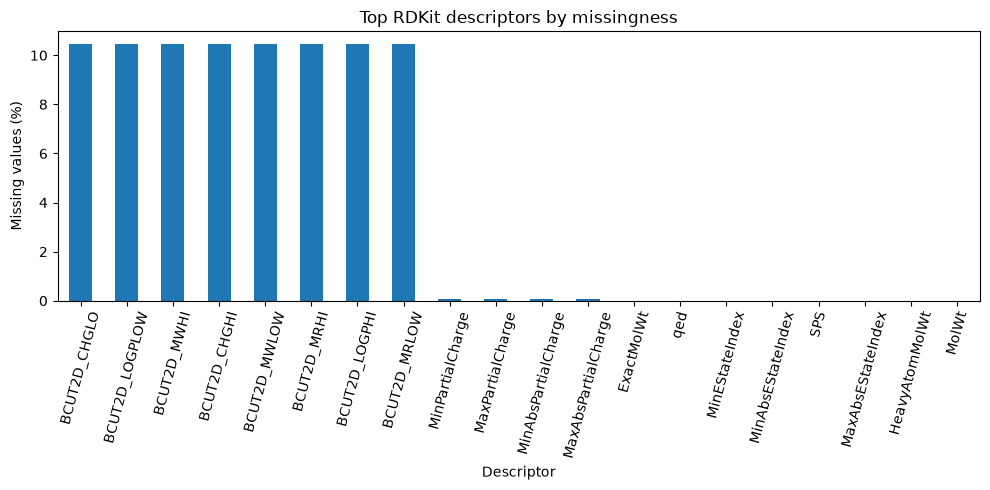

Descriptors with missing values: 12
Constant descriptors: 6


In [28]:
# ---------- RDKit descriptor diagnostics ----------
descriptor_missing_pct = 100 * rdkit_descriptors.isna().mean()

fig, ax = plt.subplots(figsize=(10, 5))

descriptor_missing_pct.sort_values(ascending=False).head(20).plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Top RDKit descriptors by missingness")
ax.set_xlabel("Descriptor")
ax.set_ylabel("Missing values (%)")
ax.tick_params(axis="x", rotation=75)

fig.tight_layout()
fig.savefig(
    FEATURE_FIGURE_DIR / "rdkit_descriptor_missingness.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(
    "Descriptors with missing values:",
    int((descriptor_missing_pct > 0).sum())
)
print(
    "Constant descriptors:",
    int((descriptor_quality["n_unique"] <= 1).sum())
)


In [29]:
# Correlation diagnostics use temporary median imputation only for this analysis.
descriptor_for_corr = rdkit_descriptors.copy()
descriptor_for_corr = descriptor_for_corr.loc[
    :,
    descriptor_for_corr.nunique(dropna=True) > 1,
]

descriptor_for_corr = descriptor_for_corr.fillna(
    descriptor_for_corr.median(numeric_only=True)
)

corr = descriptor_for_corr.corr(method="pearson").abs()

upper_mask = np.triu(
    np.ones(corr.shape, dtype=bool),
    k=1,
)

upper_corr = corr.where(upper_mask)

high_corr_pairs = (
    upper_corr.stack()
    .rename("abs_correlation")
    .sort_values(ascending=False)
)

print(f"Descriptor pairs with |r| > 0.90: {(high_corr_pairs > 0.90).sum()}")
print(f"Descriptor pairs with |r| > 0.95: {(high_corr_pairs > 0.95).sum()}")

display(
    high_corr_pairs.head(25).to_frame()
)


Descriptor pairs with |r| > 0.90: 905
Descriptor pairs with |r| > 0.95: 366


abs_correlation
fr_Ar_NH               fr_Nhpyrrole           1.000000
NumAmideBonds          fr_amide               1.000000
MaxAbsEStateIndex      MaxEStateIndex         1.000000
MolWt                  ExactMolWt             1.000000
                       HeavyAtomMolWt         0.999844
HeavyAtomMolWt         ExactMolWt             0.999842
Chi1                   HeavyAtomCount         0.999603
NumValenceElectrons    HeavyAtomCount         0.999350
                       Chi0                   0.999328
Chi0                   HeavyAtomCount         0.999310
Chi0v                  LabuteASA              0.999272
Chi0                   Chi1                   0.999091
NumAromaticCarbocycles fr_benzene             0.999020
NumValenceElectrons    Chi1                   0.998743
                       Chi0n                  0.998565
Chi0n                  Chi1n                  0.998499
                       HeavyAtomCount         0.998412
                       Chi1                   0.998150
Chi0                   Chi0n                  0.998012
Kappa2                 Phi                    0.997911
ExactMolWt             LabuteASA              0.997777
Chi1                   MolMR                  0.997775
MolWt                  LabuteASA              0.997774
LabuteASA              HeavyAtomCount         0.997718
Chi0n                  MolMR                  0.997519

In [30]:
# PCA of the full RDKit descriptor representation.
# This preprocessing is for visualization/EDA only.

X_desc = rdkit_descriptors.copy()

# Make sure everything is numeric.
X_desc = X_desc.apply(pd.to_numeric, errors="coerce")

# Convert infinities to missing values.
X_desc = X_desc.replace([np.inf, -np.inf], np.nan)

# Drop descriptors that are completely missing.
all_missing = X_desc.columns[X_desc.isna().all()]
X_desc = X_desc.drop(columns=all_missing)

print(f"Dropped all-missing descriptors: {len(all_missing)}")

# Drop constant descriptors.
constant_columns = X_desc.columns[
    X_desc.nunique(dropna=True) <= 1
]

X_desc = X_desc.drop(columns=constant_columns)

print(f"Dropped constant descriptors: {len(constant_columns)}")

# Median imputation.
descriptor_imputer = SimpleImputer(strategy="median")

X_desc_imputed = descriptor_imputer.fit_transform(X_desc)

X_desc_imputed = pd.DataFrame(
    X_desc_imputed,
    columns=X_desc.columns,
    index=X_desc.index,
)

print(
    "Non-finite values after imputation:",
    (~np.isfinite(X_desc_imputed.to_numpy())).sum()
)

# --------------------------------------------------
# Detect numerically extreme descriptor columns
# --------------------------------------------------

descriptor_max_abs = X_desc_imputed.abs().max()

extreme_columns = descriptor_max_abs[
    descriptor_max_abs > 1e100
].index

print(
    f"Numerically extreme descriptors removed for PCA: "
    f"{len(extreme_columns)}"
)

if len(extreme_columns) > 0:
    display(
        descriptor_max_abs.loc[extreme_columns]
        .sort_values(ascending=False)
        .to_frame("max_absolute_value")
    )

X_desc_pca_input = X_desc_imputed.drop(
    columns=extreme_columns
)

# --------------------------------------------------
# Scale
# --------------------------------------------------

descriptor_scaler = StandardScaler()

X_desc_scaled = descriptor_scaler.fit_transform(
    X_desc_pca_input
)

# Check which columns, if any, still cause problems.
bad_scaled_columns = X_desc_pca_input.columns[
    ~np.isfinite(X_desc_scaled).all(axis=0)
]

print(
    f"Descriptors still producing non-finite scaled values: "
    f"{len(bad_scaled_columns)}"
)

if len(bad_scaled_columns) > 0:
    print(list(bad_scaled_columns))

    # Remove them for this PCA visualization.
    X_desc_pca_input = X_desc_pca_input.drop(
        columns=bad_scaled_columns
    )

    X_desc_scaled = StandardScaler().fit_transform(
        X_desc_pca_input
    )

print(
    "Final PCA input shape:",
    X_desc_scaled.shape
)

print(
    "Non-finite values before PCA:",
    (~np.isfinite(X_desc_scaled)).sum()
)

assert np.isfinite(X_desc_scaled).all()

# --------------------------------------------------
# PCA
# --------------------------------------------------

descriptor_pca = PCA(n_components=2)

X_desc_pca = descriptor_pca.fit_transform(
    X_desc_scaled
)

feature_viz = feature_ids.copy()

feature_viz["descriptor_PC1"] = X_desc_pca[:, 0]
feature_viz["descriptor_PC2"] = X_desc_pca[:, 1]

print(
    "Descriptor PCA explained variance:",
    f"PC1={descriptor_pca.explained_variance_ratio_[0]:.3f},",
    f"PC2={descriptor_pca.explained_variance_ratio_[1]:.3f},",
    f"total={descriptor_pca.explained_variance_ratio_[:2].sum():.3f}",
)

Dropped all-missing descriptors: 0
Dropped constant descriptors: 6
Non-finite values after imputation: 0
Numerically extreme descriptors removed for PCA: 1


,max_absolute_value
Ipc,2.582738e+198


Descriptors still producing non-finite scaled values: 0
Final PCA input shape: (1215, 210)
Non-finite values before PCA: 0
Descriptor PCA explained variance: PC1=0.308, PC2=0.051, total=0.360


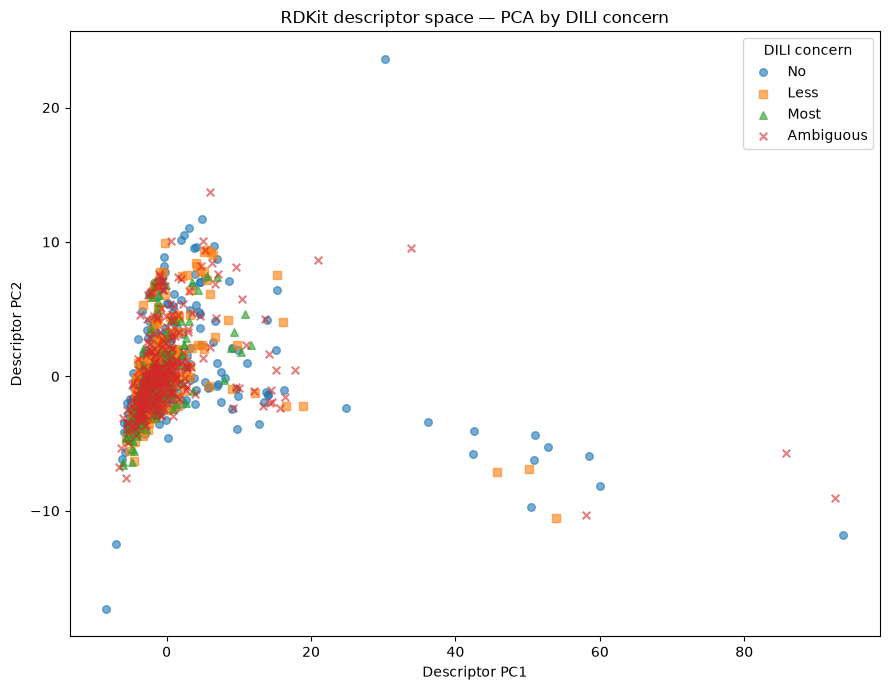

In [31]:
CONCERN_DISPLAY_MAP = {
    "vNo-DILI-concern": "No",
    "vLess-DILI-concern": "Less",
    "vMost-DILI-concern": "Most",
    "Ambiguous-DILI-concern": "Ambiguous",
}

feature_viz["ConcernDisplay"] = (
    feature_viz["vDILI-Concern"]
    .map(CONCERN_DISPLAY_MAP)
    .fillna(feature_viz["vDILI-Concern"])
)

concern_order = [
    x for x in ["No", "Less", "Most", "Ambiguous"]
    if x in set(feature_viz["ConcernDisplay"].dropna())
]

fig, ax = plt.subplots(figsize=(9, 7))
markers = ["o", "s", "^", "x"]

for marker, label in zip(markers, concern_order):
    subset = feature_viz.loc[
        feature_viz["ConcernDisplay"] == label
    ]

    ax.scatter(
        subset["descriptor_PC1"],
        subset["descriptor_PC2"],
        label=label,
        marker=marker,
        alpha=0.6,
        s=30,
    )

ax.set_title("RDKit descriptor space — PCA by DILI concern")
ax.set_xlabel("Descriptor PC1")
ax.set_ylabel("Descriptor PC2")
ax.legend(title="DILI concern")

fig.tight_layout()
fig.savefig(
    FEATURE_FIGURE_DIR / "rdkit_descriptor_pca_concern.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


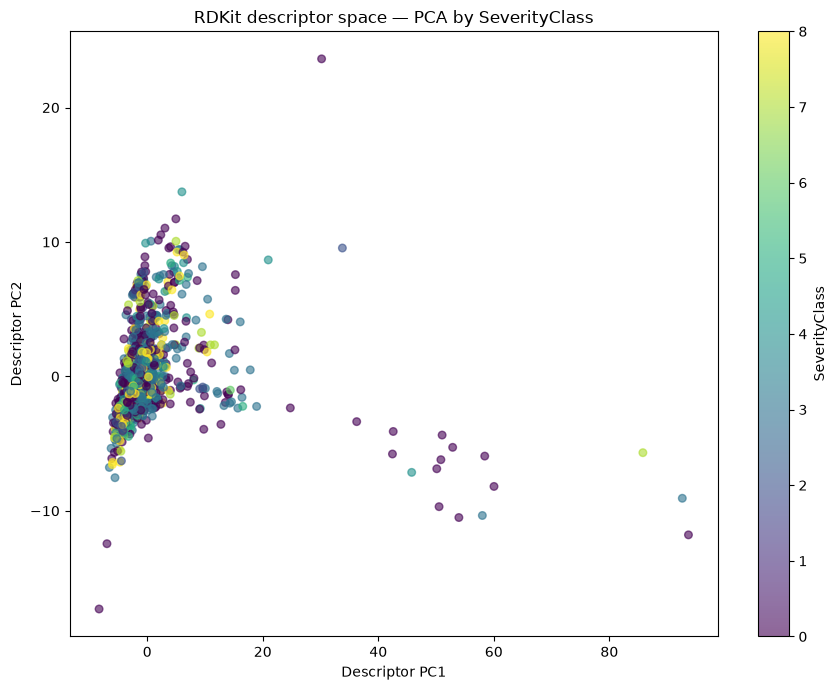

In [32]:
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    feature_viz["descriptor_PC1"],
    feature_viz["descriptor_PC2"],
    c=feature_viz["SeverityClass"].astype(float),
    cmap="viridis",
    alpha=0.6,
    s=30,
)

ax.set_title("RDKit descriptor space — PCA by SeverityClass")
ax.set_xlabel("Descriptor PC1")
ax.set_ylabel("Descriptor PC2")

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("SeverityClass")

severity_ticks = sorted(
    feature_viz["SeverityClass"]
    .dropna()
    .astype(int)
    .unique()
)
cbar.set_ticks(severity_ticks)

fig.tight_layout()
fig.savefig(
    FEATURE_FIGURE_DIR / "rdkit_descriptor_pca_severity.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


Active bits per molecule — median: 47, mean: 50.0, min: 1, max: 213
Never-active Morgan bits: 7
Bits present in <1% of compounds: 988
Bits present in >50% of compounds: 9


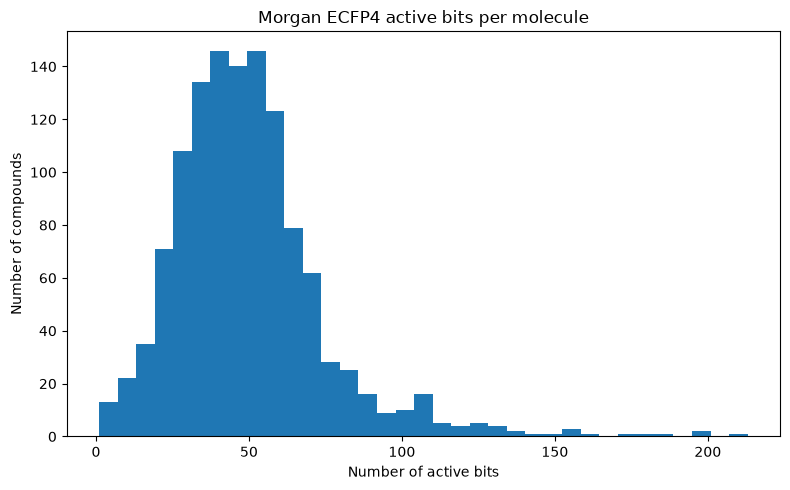

In [33]:
# ---------- Morgan fingerprint diagnostics ----------
active_bits_per_molecule = morgan_matrix.sum(axis=1)
bit_prevalence = morgan_matrix.mean(axis=0)

print(
    f"Active bits per molecule — median: {np.median(active_bits_per_molecule):.0f}, "
    f"mean: {active_bits_per_molecule.mean():.1f}, "
    f"min: {active_bits_per_molecule.min()}, "
    f"max: {active_bits_per_molecule.max()}"
)

print(f"Never-active Morgan bits: {(bit_prevalence == 0).sum()}")
print(f"Bits present in <1% of compounds: {(bit_prevalence < 0.01).sum()}")
print(f"Bits present in >50% of compounds: {(bit_prevalence > 0.50).sum()}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(active_bits_per_molecule, bins=35)
ax.set_title("Morgan ECFP4 active bits per molecule")
ax.set_xlabel("Number of active bits")
ax.set_ylabel("Number of compounds")

fig.tight_layout()
fig.savefig(
    FEATURE_FIGURE_DIR / "morgan_active_bits_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


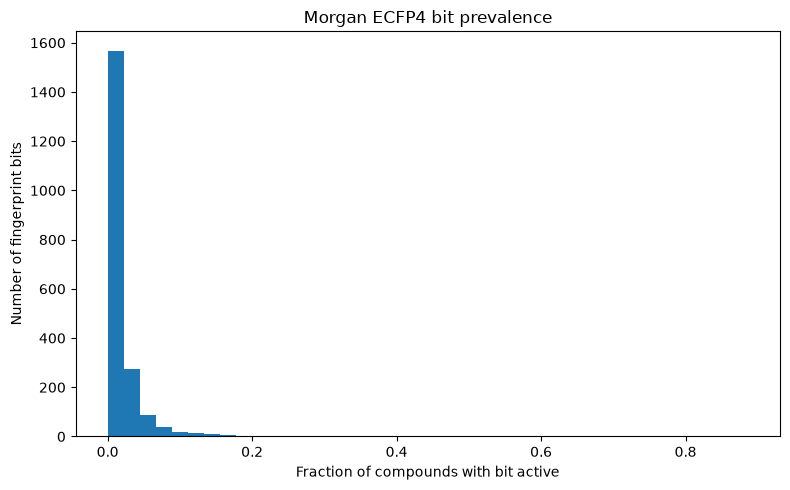

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(bit_prevalence, bins=40)
ax.set_title("Morgan ECFP4 bit prevalence")
ax.set_xlabel("Fraction of compounds with bit active")
ax.set_ylabel("Number of fingerprint bits")

fig.tight_layout()
fig.savefig(
    FEATURE_FIGURE_DIR / "morgan_bit_prevalence.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


In [35]:
# Truncated SVD gives a simple 2D view of the high-dimensional binary fingerprint matrix.
morgan_svd = TruncatedSVD(
    n_components=2,
    random_state=RANDOM_STATE,
)

X_morgan_svd = morgan_svd.fit_transform(morgan_matrix)

feature_viz["morgan_SVD1"] = X_morgan_svd[:, 0]
feature_viz["morgan_SVD2"] = X_morgan_svd[:, 1]

print(
    "Morgan SVD explained variance:",
    f"component 1={morgan_svd.explained_variance_ratio_[0]:.3f},",
    f"component 2={morgan_svd.explained_variance_ratio_[1]:.3f},",
    f"total={morgan_svd.explained_variance_ratio_[:2].sum():.3f}",
)


Morgan SVD explained variance: component 1=0.026, component 2=0.038, total=0.064


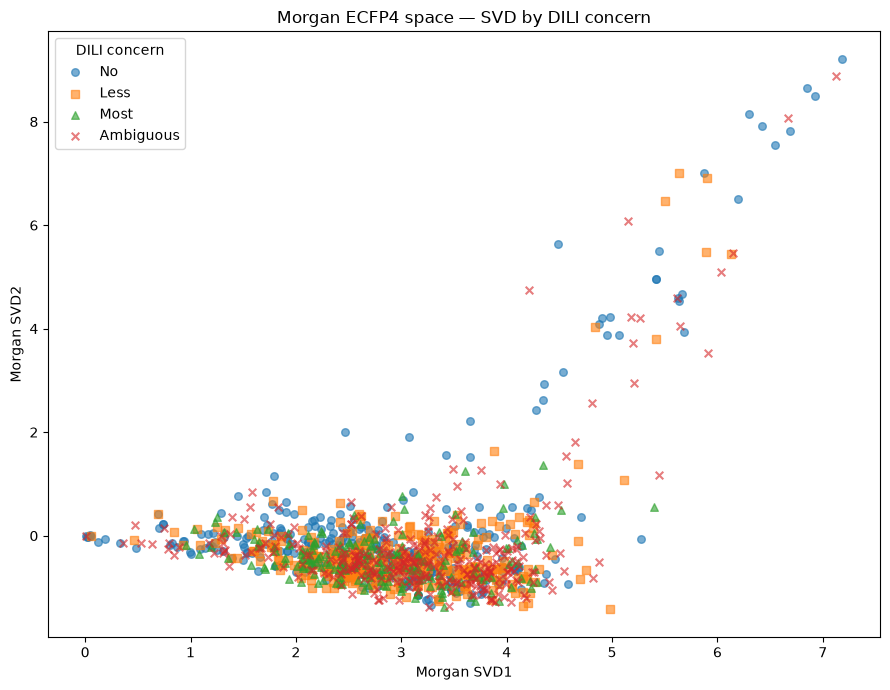

In [36]:
fig, ax = plt.subplots(figsize=(9, 7))

for marker, label in zip(markers, concern_order):
    subset = feature_viz.loc[
        feature_viz["ConcernDisplay"] == label
    ]

    ax.scatter(
        subset["morgan_SVD1"],
        subset["morgan_SVD2"],
        label=label,
        marker=marker,
        alpha=0.6,
        s=30,
    )

ax.set_title("Morgan ECFP4 space — SVD by DILI concern")
ax.set_xlabel("Morgan SVD1")
ax.set_ylabel("Morgan SVD2")
ax.legend(title="DILI concern")

fig.tight_layout()
fig.savefig(
    FEATURE_FIGURE_DIR / "morgan_svd_concern.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


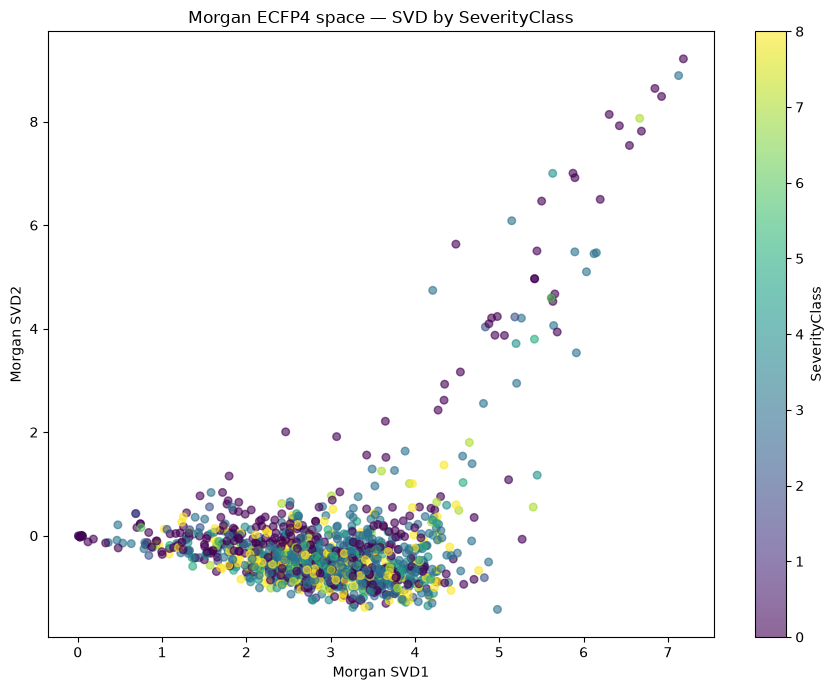

In [37]:
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    feature_viz["morgan_SVD1"],
    feature_viz["morgan_SVD2"],
    c=feature_viz["SeverityClass"].astype(float),
    cmap="viridis",
    alpha=0.6,
    s=30,
)

ax.set_title("Morgan ECFP4 space — SVD by SeverityClass")
ax.set_xlabel("Morgan SVD1")
ax.set_ylabel("Morgan SVD2")

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("SeverityClass")
cbar.set_ticks(severity_ticks)

fig.tight_layout()
fig.savefig(
    FEATURE_FIGURE_DIR / "morgan_svd_severity.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


### Interpretation guardrail

These diagnostics tell us whether the feature representations are well behaved, redundant, sparse, or visibly structured.

They are **not used to manually select predictors**. Any imputation, scaling, variance filtering, correlation filtering, or supervised feature selection used by a model must still be fit only on the training portion of each cross-validation iteration.

## 7. Define the main No / Less / Most modelling population

The feature matrices above include every structure-resolved compound.

The core benchmark now selects only the three ordered DILI-concern classes. Ambiguous compounds remain available in the feature files for later extensions.


In [38]:
TARGET_MAP = {
    "vNo-DILI-concern": ("No", 0),
    "vLess-DILI-concern": ("Less", 1),
    "vMost-DILI-concern": ("Most", 2),
}

model_mask = data["vDILI-Concern"].isin(TARGET_MAP)

model_data = data.loc[
    model_mask,
    [
        "LTKBID",
        "CompoundName",
        "vDILI-Concern",
        "SMILES_standardized",
        "SMILES_parent",
        "InChIKey_parent",
    ],
].copy()

model_data["feature_row"] = feature_ids.loc[model_mask, "feature_row"].to_numpy()
model_data["DILI_class"] = model_data["vDILI-Concern"].map(
    {key: value[0] for key, value in TARGET_MAP.items()}
)
model_data["DILI_order"] = model_data["vDILI-Concern"].map(
    {key: value[1] for key, value in TARGET_MAP.items()}
).astype(int)

model_data = model_data.reset_index(drop=True)

print(f"Structure-resolved compounds: {len(data)}")
print(f"Main No/Less/Most population: {len(model_data)}")
print(f"Excluded from main task (e.g. Ambiguous): {len(data) - len(model_data)}")
print()

display(
    model_data["DILI_class"]
    .value_counts()
    .reindex(["No", "Less", "Most"])
    .to_frame("count")
)


Structure-resolved compounds: 1215
Main No/Less/Most population: 886
Excluded from main task (e.g. Ambiguous): 329



,count
DILI_class,
No,350
Less,330
Most,206


## 8. Parent groups and Bemis–Murcko scaffold groups

### Parent grouping
`InChIKey_parent` is used to prevent parent-equivalent chemical forms from appearing in different folds.

### Scaffold grouping
Bemis–Murcko scaffolds are generated from the **parent structure**.

Acyclic molecules have no Murcko ring scaffold. They are therefore assigned their own parent-based scaffold group instead of being collapsed into one meaningless global acyclic group.


In [39]:
def murcko_scaffold_group(parent_smiles, parent_inchikey):
    mol = Chem.MolFromSmiles(str(parent_smiles))

    if mol is None:
        return f"PARENT::{parent_inchikey}"

    scaffold = MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol,
        includeChirality=False,
    )

    if scaffold:
        return f"SCAFFOLD::{scaffold}"

    return f"ACYCLIC::{parent_inchikey}"


model_data["parent_group"] = model_data["InChIKey_parent"].astype(str)
model_data["scaffold_group"] = [
    murcko_scaffold_group(smiles, inchikey)
    for smiles, inchikey in zip(
        model_data["SMILES_parent"],
        model_data["InChIKey_parent"],
    )
]

print(f"Unique parent groups:   {model_data['parent_group'].nunique()}")
print(f"Unique scaffold groups: {model_data['scaffold_group'].nunique()}")

scaffold_sizes = model_data["scaffold_group"].value_counts()
print(f"Singleton scaffold groups: {(scaffold_sizes == 1).sum()}")
print(f"Largest scaffold group:    {scaffold_sizes.max()}")


Unique parent groups:   880
Unique scaffold groups: 633
Singleton scaffold groups: 535
Largest scaffold group:    75


## 9. Helper functions for fixed 5-fold assignments

Each compound receives one integer fold label from `0` to `4`.

That fold number denotes the **outer test fold** in later notebooks. All remaining folds are training data for that outer iteration.


In [40]:
def make_stratified_group_folds(y, groups, n_splits=5, random_state=42):
    splitter = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    folds = np.full(len(y), -1, dtype=int)
    dummy_X = np.zeros((len(y), 1), dtype=np.uint8)

    for fold, (_, test_idx) in enumerate(splitter.split(dummy_X, y, groups)):
        folds[test_idx] = fold

    if np.any(folds < 0):
        raise RuntimeError("Some compounds were not assigned to an outer fold.")

    return folds


def fold_class_table(frame, fold_column):
    table = pd.crosstab(frame[fold_column], frame["DILI_class"])
    desired = [x for x in ["No", "Less", "Most"] if x in table.columns]
    return table.reindex(index=range(N_SPLITS), columns=desired, fill_value=0)


def validate_group_integrity(frame, fold_column, group_column):
    n_folds_per_group = frame.groupby(group_column)[fold_column].nunique()
    leaking_groups = n_folds_per_group[n_folds_per_group > 1]

    if len(leaking_groups):
        raise AssertionError(
            f"{len(leaking_groups)} {group_column} groups appear in more than one {fold_column}."
        )

    return len(leaking_groups)


## 10. Stratified parent-grouped random CV

This is the benchmark's "random" evaluation regime.

It is approximately stratified/random, but compounds sharing the same parent structure are forced to remain in the same fold to prevent obvious chemical leakage.


In [41]:
model_data["random_fold"] = make_stratified_group_folds(
    y=model_data["DILI_class"].to_numpy(),
    groups=model_data["parent_group"].to_numpy(),
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
)

random_leaks = validate_group_integrity(
    model_data,
    fold_column="random_fold",
    group_column="parent_group",
)

print(f"Parent-group leakage across random folds: {random_leaks}")
display(fold_class_table(model_data, "random_fold"))


Parent-group leakage across random folds: 0


DILI_class,No,Less,Most
random_fold,,,
0,70,66,42
1,70,66,41
2,70,66,41
3,70,66,41
4,70,66,41


In [42]:
random_fold_sizes = (
    model_data["random_fold"]
    .value_counts()
    .sort_index()
    .rename("n_compounds")
    .to_frame()
)

random_fold_sizes["percentage"] = 100 * random_fold_sizes["n_compounds"] / len(model_data)
display(random_fold_sizes.round(1))


,n_compounds,percentage
random_fold,,
0,178,20.1
1,177,20.0
2,177,20.0
3,177,20.0
4,177,20.0


## 11. Scaffold-grouped CV

This is the harder chemical-generalization regime.

All compounds belonging to the same scaffold group are assigned to the same outer fold. The stratified grouped splitter attempts to keep class distributions reasonably balanced while respecting scaffold groups.


In [43]:
model_data["scaffold_fold"] = make_stratified_group_folds(
    y=model_data["DILI_class"].to_numpy(),
    groups=model_data["scaffold_group"].to_numpy(),
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
)

scaffold_leaks = validate_group_integrity(
    model_data,
    fold_column="scaffold_fold",
    group_column="scaffold_group",
)

print(f"Scaffold-group leakage across scaffold folds: {scaffold_leaks}")
display(fold_class_table(model_data, "scaffold_fold"))


Scaffold-group leakage across scaffold folds: 0


DILI_class,No,Less,Most
scaffold_fold,,,
0,69,66,41
1,71,67,41
2,70,66,42
3,69,65,41
4,71,66,41


In [44]:
scaffold_fold_sizes = (
    model_data["scaffold_fold"]
    .value_counts()
    .sort_index()
    .rename("n_compounds")
    .to_frame()
)

scaffold_fold_sizes["percentage"] = 100 * scaffold_fold_sizes["n_compounds"] / len(model_data)
display(scaffold_fold_sizes.round(1))


,n_compounds,percentage
scaffold_fold,,
0,176,19.9
1,179,20.2
2,178,20.1
3,175,19.8
4,178,20.1


## 12. Split sanity checks

The saved folds must satisfy:

- every modelling compound belongs to exactly one random outer fold;
- every modelling compound belongs to exactly one scaffold outer fold;
- parent groups never cross random folds;
- scaffold groups never cross scaffold folds;
- all three target classes appear in every fold.


In [45]:
assert set(model_data["random_fold"].unique()) == set(range(N_SPLITS))
assert set(model_data["scaffold_fold"].unique()) == set(range(N_SPLITS))

assert validate_group_integrity(model_data, "random_fold", "parent_group") == 0
assert validate_group_integrity(model_data, "scaffold_fold", "scaffold_group") == 0

random_class_table = fold_class_table(model_data, "random_fold")
scaffold_class_table = fold_class_table(model_data, "scaffold_fold")

if (random_class_table == 0).any().any():
    raise AssertionError("At least one random fold is missing a target class.")

if (scaffold_class_table == 0).any().any():
    raise AssertionError("At least one scaffold fold is missing a target class.")

print("All split sanity checks passed.")


All split sanity checks passed.


## 13. Save DILI-concern modelling population and fold assignments

In [46]:
MODELLING_POPULATION_PATH = SPLIT_DIR / "concern_modelling_population.csv"
RANDOM_FOLDS_PATH = SPLIT_DIR / "concern_random_cv_folds.csv"
SCAFFOLD_FOLDS_PATH = SPLIT_DIR / "concern_scaffold_cv_folds.csv"

population_columns = [
    "feature_row",
    "LTKBID",
    "CompoundName",
    "vDILI-Concern",
    "DILI_class",
    "DILI_order",
    "InChIKey_parent",
    "parent_group",
    "scaffold_group",
    "random_fold",
    "scaffold_fold",
]

model_data[population_columns].to_csv(MODELLING_POPULATION_PATH, index=False)

model_data[[
    "feature_row",
    "LTKBID",
    "DILI_class",
    "DILI_order",
    "parent_group",
    "random_fold",
]].to_csv(RANDOM_FOLDS_PATH, index=False)

model_data[[
    "feature_row",
    "LTKBID",
    "DILI_class",
    "DILI_order",
    "scaffold_group",
    "scaffold_fold",
]].to_csv(SCAFFOLD_FOLDS_PATH, index=False)

print(f"Saved: {MODELLING_POPULATION_PATH}")
print(f"Saved: {RANDOM_FOLDS_PATH}")
print(f"Saved: {SCAFFOLD_FOLDS_PATH}")


Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/splits/concern_modelling_population.csv
Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/splits/concern_random_cv_folds.csv
Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/splits/concern_scaffold_cv_folds.csv


## 14. SeverityClass target population and CV feasibility

`SeverityClass` is retained as a **separate ordinal target** ranging from 0 to 8.

We save its target population now, but we only create fixed severity folds if the data support the same 5-fold grouped evaluation design used for the DILI-concern benchmark.

For each severity level, a valid grouped 5-fold design requires at minimum:

- at least 5 compounds;
- at least 5 independent parent groups;
- at least 5 independent scaffold groups.

This is a minimum feasibility check, not a claim that 5 observations would provide a statistically strong class estimate.

In [47]:
severity_data = data.loc[
    data["SeverityClass"].notna(),
    [
        "LTKBID",
        "CompoundName",
        "SeverityClass",
        "SMILES_standardized",
        "SMILES_parent",
        "InChIKey_parent",
    ],
].copy()

severity_data["SeverityClass"] = severity_data["SeverityClass"].astype(int)
severity_data["feature_row"] = feature_ids.loc[
    data["SeverityClass"].notna(),
    "feature_row"
].to_numpy()

severity_data["parent_group"] = severity_data["InChIKey_parent"].astype(str)

severity_data["scaffold_group"] = [
    murcko_scaffold_group(smiles, inchikey)
    for smiles, inchikey in zip(
        severity_data["SMILES_parent"],
        severity_data["InChIKey_parent"],
    )
]

severity_data = severity_data.reset_index(drop=True)

severity_counts = (
    severity_data["SeverityClass"]
    .value_counts()
    .sort_index()
)

severity_parent_groups = (
    severity_data.groupby("SeverityClass")["parent_group"]
    .nunique()
    .reindex(severity_counts.index)
)

severity_scaffold_groups = (
    severity_data.groupby("SeverityClass")["scaffold_group"]
    .nunique()
    .reindex(severity_counts.index)
)

severity_feasibility = pd.DataFrame({
    "n_compounds": severity_counts,
    "n_parent_groups": severity_parent_groups,
    "n_scaffold_groups": severity_scaffold_groups,
})

severity_feasibility["sample_ok_for_5fold"] = (
    severity_feasibility["n_compounds"] >= N_SPLITS
)

severity_feasibility["parent_groups_ok_for_5fold"] = (
    severity_feasibility["n_parent_groups"] >= N_SPLITS
)

severity_feasibility["scaffold_groups_ok_for_5fold"] = (
    severity_feasibility["n_scaffold_groups"] >= N_SPLITS
)

severity_feasibility["all_minimum_checks_pass"] = (
    severity_feasibility[
        [
            "sample_ok_for_5fold",
            "parent_groups_ok_for_5fold",
            "scaffold_groups_ok_for_5fold",
        ]
    ]
    .all(axis=1)
)

display(severity_feasibility)

severity_cv_feasible = bool(
    severity_feasibility["all_minimum_checks_pass"].all()
)

print(f"Direct 0–8 SeverityClass 5-fold grouped CV feasible: {severity_cv_feasible}")


,n_compounds,n_parent_groups,n_scaffold_groups,sample_ok_for_5fold,parent_groups_ok_for_5fold,scaffold_groups_ok_for_5fold,all_minimum_checks_pass
SeverityClass,,,,,,,
0,394,389,302,True,True,True,True
1,3,3,3,False,False,False,False
2,46,46,38,True,True,True,True
3,375,375,306,True,True,True,True
4,91,91,84,True,True,True,True
5,69,69,58,True,True,True,True
6,6,5,5,True,True,True,True
7,60,60,57,True,True,True,True
8,171,170,140,True,True,True,True


Direct 0–8 SeverityClass 5-fold grouped CV feasible: False


In [48]:
SEVERITY_POPULATION_PATH = SPLIT_DIR / "severity_population.csv"
SEVERITY_FEASIBILITY_PATH = SPLIT_DIR / "severity_cv_feasibility.csv"

severity_data[
    [
        "feature_row",
        "LTKBID",
        "CompoundName",
        "SeverityClass",
        "InChIKey_parent",
        "parent_group",
        "scaffold_group",
    ]
].to_csv(
    SEVERITY_POPULATION_PATH,
    index=False,
)

severity_feasibility.to_csv(
    SEVERITY_FEASIBILITY_PATH,
    index=True,
    index_label="SeverityClass",
)

print(f"Saved: {SEVERITY_POPULATION_PATH}")
print(f"Saved: {SEVERITY_FEASIBILITY_PATH}")


Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/splits/severity_population.csv
Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/splits/severity_cv_feasibility.csv


In [49]:
# Only create severity folds if every severity level satisfies the minimum
# sample/group requirements. Otherwise, preserve the target population and stop
# before constructing an invalid split.
SEVERITY_RANDOM_FOLDS_PATH = SPLIT_DIR / "severity_random_cv_folds.csv"
SEVERITY_SCAFFOLD_FOLDS_PATH = SPLIT_DIR / "severity_scaffold_cv_folds.csv"

if severity_cv_feasible:
    severity_data["random_fold"] = make_stratified_group_folds(
        y=severity_data["SeverityClass"].to_numpy(),
        groups=severity_data["parent_group"].to_numpy(),
        n_splits=N_SPLITS,
        random_state=RANDOM_STATE,
    )

    severity_data["scaffold_fold"] = make_stratified_group_folds(
        y=severity_data["SeverityClass"].to_numpy(),
        groups=severity_data["scaffold_group"].to_numpy(),
        n_splits=N_SPLITS,
        random_state=RANDOM_STATE,
    )

    validate_group_integrity(
        severity_data,
        fold_column="random_fold",
        group_column="parent_group",
    )

    validate_group_integrity(
        severity_data,
        fold_column="scaffold_fold",
        group_column="scaffold_group",
    )

    severity_data[
        [
            "feature_row",
            "LTKBID",
            "SeverityClass",
            "parent_group",
            "random_fold",
        ]
    ].to_csv(
        SEVERITY_RANDOM_FOLDS_PATH,
        index=False,
    )

    severity_data[
        [
            "feature_row",
            "LTKBID",
            "SeverityClass",
            "scaffold_group",
            "scaffold_fold",
        ]
    ].to_csv(
        SEVERITY_SCAFFOLD_FOLDS_PATH,
        index=False,
    )

    print("Severity folds created and saved.")
else:
    failed_levels = severity_feasibility.loc[
        ~severity_feasibility["all_minimum_checks_pass"]
    ]

    print(
        "Severity folds were NOT created because the direct 0–8 target "
        "does not satisfy the minimum requirements for grouped 5-fold CV."
    )
    display(failed_levels)


Severity folds were NOT created because the direct 0–8 target does not satisfy the minimum requirements for grouped 5-fold CV.


,n_compounds,n_parent_groups,n_scaffold_groups,sample_ok_for_5fold,parent_groups_ok_for_5fold,scaffold_groups_ok_for_5fold,all_minimum_checks_pass
SeverityClass,,,,,,,
1,3,3,3,False,False,False,False


### Severity modelling decision

If the feasibility check fails, we keep `SeverityClass` as a scientifically interesting target but **do not force a direct nine-class benchmark**.

Possible later options should be justified from the DILIrank SeverityClass definition, for example:

- a scientifically defensible regrouping of adjacent severity levels;
- a different ordinal formulation;
- a different evaluation strategy.

We should not merge severity levels solely to make cross-validation convenient.

## 15. Save feature-generation metadata

In [50]:
metadata = {
    "n_structure_resolved_compounds": int(len(data)),
    "n_main_modelling_compounds": int(len(model_data)),
    "target_classes": ["No", "Less", "Most"],
    "target_order": {"No": 0, "Less": 1, "Most": 2},
    "rdkit_descriptor_count": int(len(descriptor_names)),
    "severity_target": {
        "classes": sorted(severity_counts.index.astype(int).tolist()),
        "counts": {str(int(k)): int(v) for k, v in severity_counts.items()},
        "direct_5fold_grouped_cv_feasible": bool(severity_cv_feasible),
    },
    "morgan": {
        "radius": int(MORGAN_RADIUS),
        "n_bits": int(MORGAN_BITS),
        "binary": True,
        "description": "Morgan radius 2 / ECFP4-style fingerprint",
    },
    "cv": {
        "n_splits": int(N_SPLITS),
        "random_state": int(RANDOM_STATE),
        "random_regime": "StratifiedGroupKFold grouped by parent InChIKey",
        "scaffold_regime": (
            "StratifiedGroupKFold grouped by Bemis-Murcko scaffold; "
            "acyclic compounds grouped by parent InChIKey"
        ),
    },
    "important_note": (
        "Feature preprocessing, scaling, imputation, correlation filtering, "
        "feature selection, and hyperparameter tuning must occur inside training folds."
    ),
}

METADATA_PATH = FEATURE_DIR / "feature_generation_metadata.json"

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved: {METADATA_PATH}")
display(metadata)


Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/data/features/feature_generation_metadata.json


{'n_structure_resolved_compounds': 1215,
 'n_main_modelling_compounds': 886,
 'target_classes': ['No', 'Less', 'Most'],
 'target_order': {'No': 0, 'Less': 1, 'Most': 2},
 'rdkit_descriptor_count': 217,
 'severity_target': {'classes': [0, 1, 2, 3, 4, 5, 6, 7, 8],
  'counts': {'0': 394,
   '1': 3,
   '2': 46,
   '3': 375,
   '4': 91,
   '5': 69,
   '6': 6,
   '7': 60,
   '8': 171},
  'direct_5fold_grouped_cv_feasible': False},
 'morgan': {'radius': 2,
  'n_bits': 2048,
  'binary': True,
  'description': 'Morgan radius 2 / ECFP4-style fingerprint'},
 'cv': {'n_splits': 5,
  'random_state': 42,
  'random_regime': 'StratifiedGroupKFold grouped by parent InChIKey',
  'scaffold_regime': 'StratifiedGroupKFold grouped by Bemis-Murcko scaffold; acyclic compounds grouped by parent InChIKey'},
 'important_note': 'Feature preprocessing, scaling, imputation, correlation filtering, feature selection, and hyperparameter tuning must occur inside training folds.'}

## 16. Final output summary

After this notebook, later model notebooks should **never regenerate feature matrices or outer folds**.

They should load the saved files and use the same compounds and test-fold assignments for every model.


In [51]:
output_rows = [
    ("Feature row mapping", FEATURE_IDS_PATH),
    ("RDKit descriptor matrix", RDKit_DESCRIPTOR_PATH),
    ("RDKit descriptor quality report", RDKit_DESCRIPTOR_QUALITY_PATH),
    ("Morgan ECFP4 matrix", MORGAN_PATH),
    ("Concern modelling population", MODELLING_POPULATION_PATH),
    ("Concern random grouped CV folds", RANDOM_FOLDS_PATH),
    ("Concern scaffold CV folds", SCAFFOLD_FOLDS_PATH),
    ("Severity target population", SEVERITY_POPULATION_PATH),
    ("Severity CV feasibility report", SEVERITY_FEASIBILITY_PATH),
    ("Feature-generation metadata", METADATA_PATH),
]

if severity_cv_feasible:
    output_rows.extend([
        ("Severity random grouped CV folds", SEVERITY_RANDOM_FOLDS_PATH),
        ("Severity scaffold CV folds", SEVERITY_SCAFFOLD_FOLDS_PATH),
    ])

outputs = pd.DataFrame({
    "artifact": [name for name, _ in output_rows],
    "path": [
        str(path.relative_to(PROJECT_ROOT))
        for _, path in output_rows
    ],
})

display(outputs)

print()
print("Main DILI-concern modelling class distribution:")
display(
    model_data["DILI_class"]
    .value_counts()
    .reindex(["No", "Less", "Most"])
    .to_frame("count")
)

print()
print("Concern random grouped folds:")
display(random_class_table)

print()
print("Concern scaffold folds:")
display(scaffold_class_table)

print()
print("SeverityClass distribution:")
display(severity_counts.to_frame("count"))

print()
print(f"Direct SeverityClass 0–8 grouped 5-fold CV feasible: {severity_cv_feasible}")


,artifact,path
0,Feature row mapping,data/features/feature_ids.csv
1,RDKit descriptor matrix,data/features/rdkit_descriptors.csv
2,RDKit descriptor quality report,data/features/rdkit_descriptor_quality.csv
3,Morgan ECFP4 matrix,data/features/morgan_ecfp4_2048.npz
4,Concern modelling population,data/splits/concern_modelling_population.csv
5,Concern random grouped CV folds,data/splits/concern_random_cv_folds.csv
6,Concern scaffold CV folds,data/splits/concern_scaffold_cv_folds.csv
7,Severity target population,data/splits/severity_population.csv
8,Severity CV feasibility report,data/splits/severity_cv_feasibility.csv
9,Feature-generation metadata,data/features/feature_generation_metadata.json



Main DILI-concern modelling class distribution:


,count
DILI_class,
No,350
Less,330
Most,206



Concern random grouped folds:


DILI_class,No,Less,Most
random_fold,,,
0,70,66,42
1,70,66,41
2,70,66,41
3,70,66,41
4,70,66,41



Concern scaffold folds:


DILI_class,No,Less,Most
scaffold_fold,,,
0,69,66,41
1,71,67,41
2,70,66,42
3,69,65,41
4,71,66,41



SeverityClass distribution:


,count
SeverityClass,
0,394
1,3
2,46
3,375
4,91
5,69
6,6
7,60
8,171



Direct SeverityClass 0–8 grouped 5-fold CV feasible: False


## Notebook Complete

The molecular feature space and the primary DILI-concern benchmark are now frozen.

### Saved feature representations
- raw RDKit 2D descriptors;
- Morgan / ECFP4-style 2048-bit fingerprints.

### Saved DILI-concern experiment
- No / Less / Most target population;
- parent-grouped random folds;
- scaffold-grouped folds.

### SeverityClass
The complete 0–8 target population and a formal 5-fold feasibility report are also saved. Severity folds are created only if every level has enough samples and independent chemical groups.

The next modelling notebook should therefore start with the validated DILI-concern experiment. Severity modelling can proceed once its evaluation design is scientifically defensible.
